# ROI Calculator

Return on Investment (ROI) is used to compare the value of an investment with the earnings it generates. It helps to measure the profitability or loss of investment, and it is expressed in percentage. Code that I found on the Internet is from YouTuber named Derrick Sherrill. In the video, he was assuming himself purchasing a rental property. This is the formula that will be used:

$ROI = \left( \frac{\text{Net Profit}}{\text{Investment}} \right) \times 100$

# Algorithm of the code:

1. Define cost rates for wick (per cm), blend (per liter), and labor (per hour):
    
    ${\text{Wick (cm)}} = \text{0.50}$

    ${\text{Blend (L)}} = \text{2.00}$

    ${\text{Labor (hr)}} = \text{5.00}$

2. Define product data for every flavour of candles:

    ${\text{Lemon}} = \text{RM 38, 2 cm wick, 2 L candle blends, 3 hr of production time}$

    ${\text{Vanilla}} = \text{RM 34, 3 cm wick, 3 L candle blends, 2 hr of production time}$

    ${\text{Wood}} = \text{RM 30, 2 cm wick, 1 L candle blends, 4 hr of production time}$

    ${\text{Rose}} = \text{RM 42, 3 cm wick, 2 L candle blends, 4 hr of production time}$

    ${\text{Lavendar}} = \text{RM 37, 2 cm wick, 2 L candle blends, 3 hr of production time}$

    ${\text{Ocean}} = \text{RM 28, 3 cm wick, 3 L candle blends, 2 hr of production time}$

3. Define data in the table.

4. Calculate cost per unit for each candle: ${\text{product data}} \times \text{cost rates}$
    
    ${\text{Wick Cost}} = \text{Wick (cm)} \times \text{wick cost}$
    
    ${\text{Blend Cost}} = \text{Blend (L)} \times \text{blend cost}$
    
    ${\text{Labor Cost}} = \text{Time (hr)} \times \text{labor cost}$
    
    ${\text{Cost per Unit}} = \text{Wick Cost} + \text{Blend Cost} + \text{Labor Cost}$

5. Assume units sold = 100 for each candle.

6. Calculate total revenue, total cost, net profit, and ROI in percentage for each candle:
   
    ${\text{Total Revenue}} = \text{Selling Price} \times \text{Units Sold}$

    ${\text{Total Cost}} = \text{Cost per Unit} \times \text{Units Sold}$
    
    ${\text{Net Profit}} = \text{Total Revenue} - \text{Total Cost}$
    
    $ROI = \left( \frac{\text{Net Profit}}{\text{Investment}} \right) \times 100$

7. Display a summary table with:
    - Candle name and its data
    - Cost per Unit (RM)
    - Total Revenue
    - Total Cost
    - Net Profit
    - ROI (%)


# Code Documentation

This is the original code that will be modified to calculate ROI for a small candle business rather than for a rental property.

In [ ]:
Investment = 40000
Rent = 700
Loss = 1000

def ROI (Investment, Rent, Loss):
    NetProfit = Rent * 12 - Loss
    ROI = (NetProfit/Investment)*100
    print(ROI)

ROI (Investment, Rent, Loss)

18.5


# Code Modification & Demonstration

This is the fixed data that calculates the ROI for each candle type.

In [ ]:
import pandas as pd #table structure

# Define cost rates
wickcm = 0.50
blendliter = 2.00
laborhour = 5.00

# Define product data
candles = {
    'Candle': ['Lemon', 'Vanilla', 'Wood','Rose','Lavendar','Ocean'],
    'Selling Price (RM)': [38, 34, 30, 42, 37, 29],
    'Wick (cm)': [2, 3, 2, 3, 2, 3],
    'Blend (L)': [2, 3, 1, 2, 2, 3],
    'Time (hr)': [3, 2, 4, 4, 3, 2]
}

df = pd.DataFrame(candles) #output in table

# Calculate cost per unit
df['Wick Cost'] = df['Wick (cm)'] * wickcm
df['Blend Cost'] = df['Blend (L)'] * blendliter
df['Labor Cost'] = df['Time (hr)'] * laborhour
df['Cost per Unit (RM)'] = df['Wick Cost'] + df['Blend Cost'] + df['Labor Cost']

# Assume units sold
df['Units Sold'] = [100, 100, 100, 100, 100, 100]

# Revenue, cost, profit, ROI
df['Total Revenue'] = df['Selling Price (RM)'] * df['Units Sold']
df['Total Cost'] = df['Cost per Unit (RM)'] * df['Units Sold']
df['Net Profit'] = df['Total Revenue'] - df['Total Cost']
df['ROI (%)'] = (df['Net Profit'] / df['Total Cost']) * 100

df[['Candle', 'Cost per Unit (RM)', 'Total Cost', 'Total Revenue', 'Net Profit', 'ROI (%)']]

print(df)

     Candle  Selling Price (RM)  Wick (cm)  Blend (L)  Time (hr)  Wick Cost  \
0     Lemon                  38          2          2          3        1.0   
1   Vanilla                  34          3          3          2        1.5   
2      Wood                  30          2          1          4        1.0   
3      Rose                  42          3          2          4        1.5   
4  Lavendar                  37          2          2          3        1.0   
5     Ocean                  29          3          3          2        1.5   

   Blend Cost  Labor Cost  Cost per Unit (RM)  Units Sold  Total Revenue  \
0         4.0        15.0                20.0         100           3800   
1         6.0        10.0                17.5         100           3400   
2         2.0        20.0                23.0         100           3000   
3         4.0        20.0                25.5         100           4200   
4         4.0        15.0                20.0         100         

This is the bar chart for the fixed calculations.

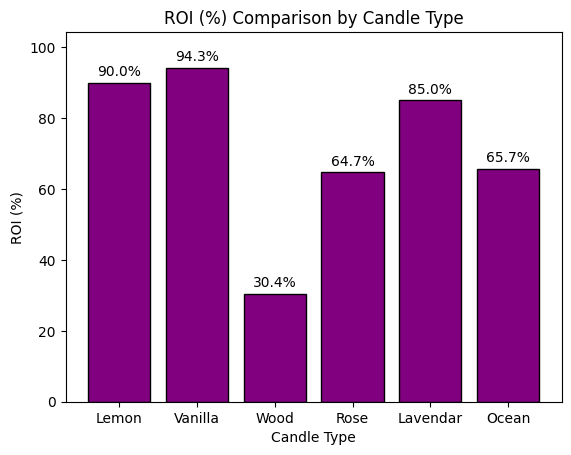

In [ ]:
import matplotlib.pyplot as plt
plt.bar(df['Candle'], df['ROI (%)'], color='purple', edgecolor='black')
plt.title('ROI (%) Comparison by Candle Type')
plt.xlabel('Candle Type')
plt.ylabel('ROI (%)')
plt.ylim(0, max(df['ROI (%)']) + 10)

for i, v in enumerate(df['ROI (%)']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')

plt.show()


This is where the founder can recalculate the cost, revenue, profit, and ROI based on their input. The founder can also make assumptions about the selling price and target number of units sold. The chart will show the new ROI for the selected candles while keeping the others unchanged.

In [ ]:
import ipywidgets as widgets # sliders,button,dropdown
import matplotlib.pyplot as plt
from IPython.display import display
candleflavour = widgets.Dropdown(options=df['Candle'].tolist(), description='Candle:') # dropdown
selling = widgets.FloatText(description='Selling Price:', value=30) #button
unit = widgets.IntSlider(description='Units Sold:', min=1, max=500, value=100) #slider
output = widgets.Output()

def calcROI(NetProfit, TotalCost):
    return ((TotalCost - NetProfit) / NetProfit) * 100 #formula ROI

def manual(change=None): #manually
    with output:
        output.clear_output() #remove old result before show new result
        selected = candleflavour.value #new selected from list
        sellingprice = selling.value #new no. of selling price
        unitsold = unit.value #new no. of sold

        idx = df[df['Candle'] == selected].index[0]
        costunit = df.at[idx, 'Cost per Unit (RM)']
        totalcost = costunit * unitsold
        totalrevenue = sellingprice * unitsold
        profit = totalrevenue - totalcost
        roi = calcROI(totalcost, totalrevenue)

        print(f"Candle: {selected}")
        print(f"Cost per unit: RM {costunit:.2f}")
        print(f"Selling price: RM {sellingprice:.2f}")
        print(f"Units sold: {unitsold}")
        print(f"Total Cost: RM {totalcost:.2f}")
        print(f"Total Revenue: RM {totalrevenue:.2f}")
        print(f"Net Profit: RM {profit:.2f}")
        print(f"ROI: {roi:.2f}%")

        # Update ROI for graph
        newgraph= df['ROI (%)'].copy()
        newgraph[idx] = roi

        plt.bar(df['Candle'], newgraph, color='orange')
        plt.title('Updated ROI (%) by Candle Type')
        plt.xlabel('Candle Type')
        plt.ylabel('ROI (%)')
        plt.ylim(0, max(df['ROI (%)']) + 10)

        for i, v in enumerate(newgraph): #i = no, of bar, v = height bar
            plt.text(i, v + 2, f"{v:.1f}%", ha='center')

        plt.show()

# Link widgets that automatically run
candleflavour.observe(manual, names='value')
selling.observe(manual, names='value')
unit.observe(manual, names='value')

display(candleflavour, selling, unit, output)
manual()


Dropdown(description='Candle:', options=('Lemon', 'Vanilla', 'Wood', 'Rose', 'Lavendar', 'Ocean'), value='Lemo…

FloatText(value=30.0, description='Selling Price:')

IntSlider(value=100, description='Units Sold:', max=500, min=1)

Output()

# References

Derrick Sherrill. (2018, November 22). Simple ROI Python Calculator - Five Minute Python Scripts - Full Code Along Walkthrough. YouTube. https://www.youtube.com/watch?v=sW-an04-ubI


‌How to make a table in Python? (2021, March 15). GeeksforGeeks. https://www.geeksforgeeks.org/how-to-make-a-table-in-python/

‌jeeteshgavande30. (2020, March 27). Bar Plot in Matplotlib. GeeksforGeeks. https://www.geeksforgeeks.org/bar-plot-in-matplotlib/